<a href="https://colab.research.google.com/github/adityab-tech/PRISMx/blob/main/notebooks/01_Data_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
import glob
import random
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip -q install yfinance nsepy pyarrow

  Preparing metadata (setup.py) ... done


In [4]:
PROJECT_ROOT = "/content/drive/MyDrive/PRISM"
folders = [ "config","data/raw","data/processed","data/final","models","notebooks","reports/figures","reports/results","src","dashboard","assets"]
for folder in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

print("Project Structure Ready!")

Project Structure Ready!


In [5]:
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "data/raw")
PROCESSED_PATH = os.path.join(PROJECT_ROOT, "data/processed")
FINAL_PATH = os.path.join(PROJECT_ROOT, "data/final")

In [6]:
stocks = [
    "3MINDIA.NS",       # 3M India Ltd.
    "AARTIDRUGS.NS",    # Aarti Drugs Ltd.
    "AAVAS.NS",         # Aavas Financiers Ltd.
    "ABB.NS",           # ABB India Ltd.
    "ABBOTINDIA.NS",    # Abbott India Ltd.
    "ABCAPITAL.NS",     # Aditya Birla Capital Ltd.
    "ABFRL.NS",         # Aditya Birla Fashion and Retail Ltd.
    "ABSLAMC.NS",       # Aditya Birla Sun Life AMC Ltd.
    "ACC.NS",           # ACC Ltd.
    "ADANIENT.NS",      # Adani Enterprises Ltd.
    "ADANIGREEN.NS",    # Adani Green Energy Ltd.
    "ADANIPORTS.NS",    # Adani Ports and Special Economic Zone Ltd.
    "ADANITRANS.NS",    # Adani Transmission Ltd.
    "ADVENZYMES.NS",    # Advanced Enzyme Tech Ltd.
    "AEGISCHEM.NS",     # Aegis Logistics Ltd.
    "AFFLE.NS",         # Affle (India) Ltd.
    "AIAENG.NS",        # AIA Engineering Ltd.
    "AJANTPHARM.NS",    # Ajanta Pharmaceuticals Ltd.
    "ALKEM.NS",         # Alkem Laboratories Ltd.
    "ALKYLAMINE.NS",    # Alkyl Amines Chemicals Ltd.
    "ALLCARGO.NS",      # Allcargo Logistics Ltd.
    "ALOKINDS.NS",      # Alok Industries Ltd.
    "AMARAJABAT.NS",    # Amara Raja Batteries Ltd.
    "AMBER.NS",         # Amber Enterprises India Ltd.
    "AMBUJACEM.NS",     # Ambuja Cements Ltd.
    "ANGELONE.NS",      # Angel One Ltd.
    "ANURAS.NS",        # Anupam Rasayan India Ltd.
    "APLAPOLLO.NS",     # APL Apollo Tubes Ltd.
    "ALEMBICPHARM.NS",  # Alembic Pharmaceuticals Ltd.
    "APOLLOHOSP.NS",    # Apollo Hospitals Enterprise Ltd.
    "APOLLOTYRE.NS",    # Apollo Tyres Ltd.
    "APTUS.NS",         # Aptus Value Housing Finance India Ltd.
    "ASAHIINDIA.NS",    # Asahi India Glass Ltd.
    "ASHOKLEY.NS",      # Ashok Leyland Ltd.
    "ASIANPAINT.NS",    # Asian Paints Ltd.
    "ASTERDM.NS",       # Aster DM Healthcare Ltd.
    "ASTRAL.NS",        # Astral Ltd.
    "ASTRAZEN.NS",      # AstraZeneca Pharma India Ltd.
    "ATGL.NS",          # Adani Total Gas Ltd.
    "ATUL.NS",          # Atul Ltd.
    "AUBANK.NS",        # AU Small Finance Bank Ltd.
    "AUROPHARMA.NS",    # Aurobindo Pharma Ltd.
    "AVANTIFEED.NS",    # Avanti Feeds Ltd.
    "AXISBANK.NS",      # Axis Bank Ltd.
    "BAJAJ-AUTO.NS",    # Bajaj Auto Ltd.
    "BAJAJELEC.NS",     # Bajaj Electricals Ltd
    "BAJAJFINSV.NS",    # Bajaj Finserv Ltd.
    "BAJAJHLDNG.NS",    # Bajaj Holdings & Investment Ltd.
    "BAJFINANCE.NS",    # Bajaj Finance Ltd.
    "BALAMINES.NS",     # Balaji Amines Ltd.
    "BALKRISIND.NS",    # Balkrishna Industries Ltd.
    "BALRAMCHIN.NS",    # Balrampur Chini Mills Ltd.
    "BANDHANBNK.NS",    # Bandhan Bank Ltd.
    "BANKBARODA.NS",    # Bank of Baroda
    "BANKINDIA.NS",     # Bank of India
    "BASF.NS",          # BASF India Ltd.
    "BATAINDIA.NS",     # Bata India Ltd.
    "BAYERCROP.NS",     # Bayer Cropscience Ltd.
    "BBTC.NS",          # Bombay Burmah Trading Corporation Ltd.
    "BCG.NS",           # Brightcom Group Ltd.
    "BDL.NS",           # Bharat Dynamics Ltd.
    "BEL.NS",           # Bharat Electronics Ltd.
    "BERGEPAINT.NS",    # Berger Paints India Ltd.
    "BHARATFORG.NS",    # Bharat Forge Ltd.
    "BHARTIARTL.NS",    # Bharti Airtel Ltd.
    "BHEL.NS",          # Bharat Heavy Electricals Ltd.
    "BIOCON.NS",        # Biocon Ltd.
    "BIRLACORPN.NS",    # Birla Corporation Ltd.
    "BLUEDART.NS",      # Blue Dart Express Ltd.
    "BLUESTARCO.NS",    # Blue Star Ltd.
    "BORORENEW.NS",     # Borosil Renewables Ltd.
    "BOSCHLTD.NS",      # Bosch Ltd.
    "BPCL.NS",          # Bharat Petroleum Corporation Ltd.
    "BRIGADE.NS",       # Brigade Enterprises Ltd.
    "BRITANNIA.NS",     # Britannia Industries Ltd.
    "BSE.NS",           # BSE Ltd.
    "BSOFT.NS",         # Birlasoft Ltd.
    "CAMS.NS",          # Computer Age Management Services Ltd.
    "CANBK.NS",         # Canara Bank
    "CANFINHOME.NS",    # Can Fin Homes Ltd.
    "CAPLIPOINT.NS",    # Caplin Point Laboratories Ltd.
    "CARBORUNIV.NS",    # Carborundum Universal Ltd.
    "CASTROLIND.NS",    # Castrol India Ltd.
    "CCL.NS",           # CCL Products (I) Ltd.
    "CDSL.NS",          # Central Depository Services (India) Ltd.
    "CEATLTD.NS",       # Ceat Ltd.
    "CENTRALBK.NS",     # Central Bank of India
    "CENTURYPLY.NS",    # Century Plyboards (India) Ltd.
    "CENTURYTEX.NS",    # Century Textile & Industries Ltd.
    "CERA.NS",          # Cera Sanitaryware Ltd
    "CESC.NS",          # CESC Ltd.
    "CGCL.NS",          # Capri Global Capital Ltd.
    "CGPOWER.NS",       # CG Power and Industrial Solutions Ltd.
    "CHALET.NS",        # Chalet Hotels Ltd.
    "CHAMBLFERT.NS",    # Chambal Fertilizers & Chemicals Ltd.
    "CHEMPLASTS.NS",    # Chemplast Sanmar Ltd.
    "CHOLAFIN.NS",      # Cholamandalam Investment and Finance Company Ltd.
    "CHOLAHLDNG.NS",    # Cholamandalam Financial Holdings Ltd.
    "CIPLA.NS",         # Cipla Ltd.
    "CLEAN.NS",         # Clean Science and Technology Ltd.
    "COALINDIA.NS",     # Coal India Ltd.
    "COCHINSHIP.NS",    # Cochin Shipyard Ltd.
    "COFORGE.NS",       # Coforge Ltd.
    "COLPAL.NS",        # Colgate Palmolive (India) Ltd.
    "CONCOR.NS",        # Container Corporation of India Ltd.
    "COROMANDEL.NS",    # Coromandel International Ltd.
    "CREDITACC.NS",     # CreditAccess Grameen Ltd.
    "CRISIL.NS",        # CRISIL Ltd.
    "CROMPTON.NS",      # Crompton Greaves Consumer Electricals Ltd.
    "CSBBANK.NS",       # CSB Bank Ltd.
    "CUB.NS",           # City Union Bank Ltd.
    "CUMMINSIND.NS",    # Cummins India Ltd.
    "CYIENT.NS",        # Cyient Ltd.
    "DABUR.NS",         # Dabur India Ltd.
    "DALBHARAT.NS",     # Dalmia Bharat Ltd.
    "DBL.NS",           # Dilip Buildcon Ltd.
    "DCMSHRIRAM.NS",    # DCM Shriram Ltd.
    "DEEPAKNTR.NS",     # Deepak Nitrite Ltd.
    "DELTACORP.NS",     # Delta Corp Ltd.
    "DEVYANI.NS",       # Devyani International Ltd.
    "DHANI.NS",         # Dhani Services Ltd.
    "DIVISLAB.NS",      # Divi's Laboratories Ltd.
    "DIXON.NS",         # Dixon Technologies (India) Ltd.
    "DLF.NS",           # DLF Ltd.
    "DMART.NS",         # Avenue Supermarts Ltd.
    "DRREDDY.NS",       # Dr. Reddy's Laboratories Ltd.
    "EASEMYTRIP.NS",    # Easy Trip Planners Ltd.
    "ECLERX.NS",        # eClerx Services Ltd.
    "EDELWEISS.NS",     # Edelweiss Financial Services Ltd.
    "EICHERMOT.NS",     # Eicher Motors Ltd.
    "EIDPARRY.NS",      # E.I.D. Parry (India) Ltd.
    "EIHOTEL.NS",       # EIH Ltd.
    "ELGIEQUIP.NS",     # Elgi Equipments Ltd.
    "EMAMILTD.NS",      # Emami Ltd.
    "ENDURANCE.NS",     # Endurance Technologies Ltd.
    "ENGINERSIN.NS",    # Engineers India Ltd.
    "EPL.NS",           # EPL Ltd.
    "EQUITASBNK.NS",    # Equitas Small Finance Bank Ltd.
    "ERIS.NS",          # Eris Lifesciences Ltd.
    "ESCORTS.NS",       # Escorts Kubota Ltd.
    "EXIDEIND.NS",      # Exide Industries Ltd.
    "FACT.NS",          # Fertilisers and Chemicals Travancore Ltd.
    "FDC.NS",           # FDC Ltd.
    "FEDERALBNK.NS",    # Federal Bank Ltd.
    "FINCABLES.NS",     # Finolex Cables Ltd.
    "FINEORG.NS",       # Fine Organic Industries Ltd.
    "FINPIPE.NS",       # Finolex Industries Ltd.
    "FLUOROCHEM.NS",    # Gujarat Fluorochemicals Ltd.
    "FORTIS.NS",        # Fortis Healthcare Ltd.
    "FSL.NS",           # Firstsource Solutions Ltd.
    "GAEL.NS",          # Gujarat Ambuja Exports Ltd.
    "GAIL.NS",          # GAIL (India) Ltd.
    "GALAXYSURF.NS",    # Galaxy Surfactants Ltd.
    "GARFIBRES.NS",     # Garware Technical Fibres Ltd.
    "GESHIP.NS",        # Great Eastern Shipping Co. Ltd.
    "GICRE.NS",         # General Insurance Corporation of India
    "GLAND.NS",         # Gland Pharma Ltd.
    "GLAXO.NS",         # Glaxosmithkline Pharmaceuticals Ltd.
    "GLENMARK.NS",      # Glenmark Pharmaceuticals Ltd.
    "GLS.NS",           # Glenmark Life Sciences Ltd.
    "GMMPFAUDLR.NS",    # GMM Pfaudler Ltd.
    "GMRINFRA.NS",      # GMR Infrastructure Ltd.
    "GNFC.NS",          # Gujarat Narmada Valley Fertilizers and Chemicals Ltd.
    "GOCOLORS.NS",      # Go Fashion (India) Ltd.
    "GODFRYPHLP.NS",    # Godfrey Phillips India Ltd.
    "GODREJAGRO.NS",    # Godrej Agrovet Ltd.
    "GODREJCP.NS",      # Godrej Consumer Products Ltd.
    "GODREJIND.NS",     # Godrej Industries Ltd.
    "GODREJPROP.NS",    # Godrej Properties Ltd.
    "GPPL.NS",          # Gujarat Pipavav Port Ltd.
    "GRANULES.NS",      # Granules India Ltd.
    "GRAPHITE.NS",      # Graphite India Ltd.
    "GRASIM.NS",        # Grasim Industries Ltd.
    "GRINDWELL.NS",     # Grindwell Norton Ltd.
    "GRINFRA.NS",       # G R Infraprojects Ltd.
    "GSFC.NS",          # Gujarat State Fertilizers & Chemicals Ltd.
    "GSPL.NS",          # Gujarat State Petronet Ltd.
    "GUJALKALI.NS",     # Gujarat Alkalies & Chemicals Ltd.
    "GUJGASLTD.NS",     # Gujarat Gas Ltd.
    "HAL.NS",           # Hindustan Aeronautics Ltd.
    "HAPPSTMNDS.NS",    # Happiest Minds Technologies Ltd.
    "HATHWAY.NS",       # Hathway Cable & Datacom Ltd.
    "HATSUN.NS",        # Hatsun Agro Product Ltd.
    "HAVELLS.NS",       # Havells India Ltd.
    "HCLTECH.NS",       # HCL Technologies Ltd.
    "HDFC.NS",          # Housing Development Finance Corporation Ltd.
    "HDFCAMC.NS",       # HDFC Asset Management Company Ltd.
    "HDFCBANK.NS",      # HDFC Bank Ltd.
    "HDFCLIFE.NS",      # HDFC Life Insurance Company Ltd.
    "HEG.NS",           # H.E.G. Ltd.
    "HEMIPROP.NS",      # Hemisphere Properties India Ltd.
    "HEROMOTOCO.NS",    # Hero MotoCorp Ltd.
    "HFCL.NS",          # HFCL Ltd.
    "HGS.NS",           # Hinduja Global Solutions Ltd.
    "HIKAL.NS",         # Hikal Ltd.
    "HINDALCO.NS",      # Hindalco Industries Ltd.
    "HINDCOPPER.NS",    # Hindustan Copper Ltd.
    "HINDPETRO.NS",     # Hindustan Petroleum Corporation Ltd.
    "HINDUNILVR.NS",    # Hindustan Unilever Ltd.
    "HINDZINC.NS",      # Hindustan Zinc Ltd.
    "HLEGLAS.NS",       # HLE Glascoat Ltd.
    "HOMEFIRST.NS",     # Home First Finance Company India Ltd.
    "HONAUT.NS",        # Honeywell Automation India Ltd.
    "HUDCO.NS",         # Housing & Urban Development Corporation Ltd.
    "IBREALEST.NS",     # Indiabulls Real Estate Ltd.
    "IBULHSGFIN.NS",    # Indiabulls Housing Finance Ltd.
    "ICICIBANK.NS",     # ICICI Bank Ltd.
    "ICICIGI.NS",       # ICICI Lombard General Insurance Company Ltd.
    "ICICIPRULI.NS",    # ICICI Prudential Life Insurance Company Ltd.
    "ICIL.NS",          # Indo Count Industries Ltd.
    "IDBI.NS",          # IDBI Bank Ltd.
    "IDEA.NS",          # Vodafone Idea Ltd.
    "IDFC.NS",          # IDFC Ltd.
    "IDFCFIRSTB.NS",    # IDFC First Bank Ltd.
    "IEX.NS",           # Indian Energy Exchange Ltd.
    "IFBIND.NS",        # IFB Industries Ltd.
    "IGL.NS",           # Indraprastha Gas Ltd.
    "IIFL.NS",          # IIFL Finance Ltd.
    "IIFLWAM.NS",       # IIFL Wealth Management Ltd.
    "INDHOTEL.NS",      # Indian Hotels Co. Ltd.
    "INDIACEM.NS",      # India Cements Ltd.
    "INDIAMART.NS",     # Indiamart Intermesh Ltd.
    "INDIANB.NS",       # Indian Bank
    "INDIGO.NS",        # InterGlobe Aviation Ltd.
    "INDIGOPNTS.NS",    # Indigo Paints Ltd.
    "INDOCO.NS",        # Indoco Remedies Ltd.
    "INDUSINDBK.NS",    # IndusInd Bank Ltd.
    "INDUSTOWER.NS",    # Indus Towers Ltd.
    "INFIBEAM.NS",      # Infibeam Avenues Ltd.
    "INFY.NS",          # Infosys Ltd.
    "INOXLEISUR.NS",    # Inox Leisure Ltd.
    "INTELLECT.NS",     # Intellect Design Arena Ltd.
    "IOB.NS",           # Indian Overseas Bank
    "IOC.NS",           # Indian Oil Corporation Ltd.
    "IPCALAB.NS",       # Ipca Laboratories Ltd.
    "IRB.NS",           # IRB Infrastructure Developers Ltd.
    "IRCON.NS",         # IRCON International Ltd.
    "IRCTC.NS",         # Indian Railway Catering And Tourism Corporation Ltd.
    "IRFC.NS",          # Indian Railway Finance Corporation Ltd.
    "ISEC.NS",          # ICICI Securities Ltd.
    "ITC.NS",           # ITC Ltd.
    "ITI.NS",           # ITI Ltd.
    "JAMNAAUTO.NS",     # Jamna Auto Industries Ltd.
    "JBCHEPHARM.NS",    # J.B. Chemicals & Pharmaceuticals Ltd.
    "JINDALSTEL.NS",    # Jindal Steel & Power Ltd.
    "JKCEMENT.NS",      # J.K. Cement Ltd.
    "JKLAKSHMI.NS",     # JK Lakshmi Cement Ltd.
    "JKPAPER.NS",       # JK Paper Ltd.
    "JMFINANCIL.NS",    # JM Financial Ltd.
    "JSL.NS",           # Jindal Stainless Ltd.
    "JSWENERGY.NS",     # JSW Energy Ltd.
    "JSWSTEEL.NS",      # JSW Steel Ltd.
    "JUBLFOOD.NS",      # Jubilant Foodworks Ltd.
    "JUBLINGREA.NS",    # Jubilant Ingrevia Ltd.
    "JUBLPHARMA.NS",    # Jubilant Pharmova Ltd.
    "JUSTDIAL.NS",      # Justdial Ltd.
    "JYOTHYLAB.NS",     # Jyothy Labs Ltd.
    "KAJARIACER.NS",    # Kajaria Ceramics Ltd.
    "KALPATPOWR.NS",    # Kalpataru Power Transmission Ltd.
    "KALYANKJIL.NS",    # Kalyan Jewellers India Ltd.
    "KANSAINER.NS",     # Kansai Nerolac Paints Ltd.
    "KARURVYSYA.NS",    # Karur Vysya Bank Ltd.
    "KEC.NS",           # Kec International Ltd.
    "KEI.NS",           # KEI Industries Ltd.
    "KIMS.NS",          # Krishna Institute of Medical Sciences Ltd.
    "KNRCON.NS",        # KNR Constructions Ltd.
    "KOTAKBANK.NS",     # Kotak Mahindra Bank Ltd.
    "KPITTECH.NS",      # KPIT Technologies Ltd.
    "KPRMILL.NS",       # K.P.R. Mill Ltd.
    "KRBL.NS",          # KRBL Ltd.
    "L&TFH.NS",         # L&T Finance Holdings Ltd.
    "LALPATHLAB.NS",    # Dr. Lal Path Labs Ltd.
    "LATENTVIEW.NS",    # Latent View Analytics Ltd.
    "LAURUSLABS.NS",    # Laurus Labs Ltd.
    "LAXMIMACH.NS",     # Lakshmi Machine Works Ltd.
    "LICHSGFIN.NS",     # LIC Housing Finance Ltd.
    "LINDEINDIA.NS",    # Linde India Ltd.
    "LODHA.NS",         # Macrotech Developers Ltd.
    "LT.NS",            # Larsen & Toubro Ltd.
    "LTI.NS",           # Larsen & Toubro Infotech Ltd.
    "LTTS.NS",          # L&T Technology Services Ltd.
    "LUPIN.NS",         # Lupin Ltd.
    "LUXIND.NS",        # Lux Industries Ltd.
    "LXCHEM.NS",        # Laxmi Organic Industries Ltd.
    "M&M.NS",           # Mahindra & Mahindra Ltd.
    "M&MFIN.NS",        # Mahindra & Mahindra Financial Services Ltd.
    "MAHABANK.NS",      # Bank of Maharashtra
    "MAHINDCIE.NS",     # Mahindra CIE Automotive Ltd.
    "MAHLOG.NS",        # Mahindra Logistics Ltd.
    "MANAPPURAM.NS",    # Manappuram Finance Ltd.
    "MAPMYINDIA.NS",    # C.E. Info Systems Ltd.
    "MARICO.NS",        # Marico Ltd.
    "MARUTI.NS",        # Maruti Suzuki India Ltd.
    "MASTEK.NS",        # Mastek Ltd.
    "MAXHEALTH.NS",     # Max Healthcare Institute Ltd.
    "MAZDOCK.NS",       # Mazagoan Dock Shipbuilders Ltd.
    "MCDOWELL-N.NS",    # United Spirits Ltd.
    "MCX.NS",           # Multi Commodity Exchange of India Ltd.
    "MEDPLUS.NS",       # Medplus Health Services Ltd.
    "METROBRAND.NS",    # Metro Brands Ltd.
    "METROPOLIS.NS",    # Metropolis Healthcare Ltd.
    "MFSL.NS",          # Max Financial Services Ltd.
    "MGL.NS",           # Mahanagar Gas Ltd.
    "MHRIL.NS",         # Mahindra Holidays & Resorts India Ltd.
    "MINDACORP.NS",     # Minda Industries Ltd.
    "MINDTREE.NS",      # MindTree Ltd.
    "MMTC.NS",          # MMTC Ltd.
    "MOIL.NS",          # MOIL Ltd.
    "MOTILALOFS.NS",    # Motilal Oswal Financial Services Ltd.
    "MPHASIS.NS",       # MphasiS Ltd.
    "MRF.NS",           # MRF Ltd.
    "MRPL.NS",          # Mangalore Refinery & Petrochemicals Ltd.
    "MTARTECH.NS",      # MTAR Technologies Ltd.
    "MUTHOOTFIN.NS",    # Muthoot Finance Ltd.
    "NAM-INDIA.NS",     # Nippon Life India Asset Management Ltd.
    "NATCOPHARM.NS",    # NATCO Pharma Ltd.
    "NATIONALUM.NS",    # National Aluminium Co. Ltd.
    "NAUKRI.NS",        # Info Edge (India) Ltd.
    "NAVINFLUOR.NS",    # Navin Fluorine International Ltd.
    "NAZARA.NS",        # Nazara Technologies Ltd.
    "NBCC.NS",          # NBCC (India) Ltd.
    "NCC.NS",           # NCC Ltd.
    "NESCO.NS",         # NESCO Ltd.
    "NESTLEIND.NS",     # Nestle India Ltd.
    "NETWORK18.NS",     # Network18 Media & Investments Ltd.
    "NH.NS",            # Narayana Hrudayalaya Ltd.
    "NHPC.NS",          # NHPC Ltd.
    "NIACL.NS",         # The New India Assurance Company Ltd.
    "NLCINDIA.NS",      # NLC India Ltd.
    "NMDC.NS",          # NMDC Ltd.
    "NOCIL.NS",         # NOCIL Ltd.
    "NTPC.NS",          # NTPC Ltd.
    "NUVOCO.NS",        # Nuvoco Vistas Corporation Ltd.
    "NYKAA.NS",         # FSN E-Commerce Ventures Ltd.
    "OBEROIRLTY.NS",    # Oberoi Realty Ltd.
    "OFSS.NS",          # Oracle Financial Services Software Ltd.
    "OIL.NS",           # Oil India Ltd.
    "ONGC.NS",          # Oil & Natural Gas Corporation Ltd.
    "ORIENTELEC.NS",    # Orient Electric Ltd.
    "PAGEIND.NS",       # Page Industries Ltd.
    "PAYTM.NS",         # One 97 Communications Ltd.
    "PCBL.NS",          # PCBL Ltd.
    "PEL.NS",           # Piramal Enterprises Ltd.
    "PERSISTENT.NS",    # Persistent Systems Ltd.
    "PETRONET.NS",      # Petronet LNG Ltd.
    "PFC.NS",           # Power Finance Corporation Ltd.
    "PFIZER.NS",        # Pfizer Ltd.
    "PGHH.NS",          # Procter & Gamble Hygiene & Health Care Ltd.
    "PGHL.NS",          # Procter & Gamble Health Ltd.
    "PHOENIXLTD.NS",    # Phoenix Mills Ltd.
    "PIDILITIND.NS",    # Pidilite Industries Ltd.
    "PIIND.NS",         # PI Industries Ltd.
    "PNB.NS",           # Punjab National Bank
    "PNBHOUSING.NS",    # PNB Housing Finance Ltd.
    "PNCINFRA.NS",      # PNC Infratech Ltd.
    "POLICYBZR.NS",     # PB Fintech Ltd.
    "POLYCAB.NS",       # Polycab India Ltd.
    "POLYMED.NS",       # Poly Medicure Ltd.
    "POLYPLEX.NS",      # Polyplex Corporation Ltd.
    "POONAWALLA.NS",    # Poonawalla Fincorp Ltd.
    "POWERGRID.NS",     # Power Grid Corporation of India Ltd.
    "POWERINDIA.NS",    # Hitachi Energy India Ltd.
    "PRAJIND.NS",       # Praj Industries Ltd.
    "PRESTIGE.NS",      # Prestige Estates Projects Ltd.
    "PRINCEPIPE.NS",    # Prince Pipes and Fittings Ltd.
    "PRIVISCL.NS",      # Privi Speciality Chemicals Ltd.
    "PRSMJOHNSN.NS",    # Prism Johnson Ltd.
    "PVR.NS",           # PVR Ltd.
    "QUESS.NS",         # Quess Corp Ltd.
    "RADICO.NS",        # Radico Khaitan Ltd
    "RAILTEL.NS",       # Railtel Corporation Of India Ltd.
    "RAIN.NS",          # Rain Industries Ltd
    "RAJESHEXPO.NS",    # Rajesh Exports Ltd.
    "RALLIS.NS",        # Rallis India Ltd.
    "RAMCOCEM.NS",      # The Ramco Cements Ltd.
    "RATNAMANI.NS",     # Ratnamani Metals & Tubes Ltd.
    "RBA.NS",           # Restaurant Brands Asia Ltd.
    "RBLBANK.NS",       # RBL Bank Ltd.
    "RCF.NS",           # Rashtriya Chemicals & Fertilizers Ltd.
    "RECLTD.NS",        # REC Ltd.
    "REDINGTON.NS",     # Redington (India) Ltd.
    "RELAXO.NS",        # Relaxo Footwears Ltd.
    "RELIANCE.NS",      # Reliance Industries Ltd.
    "RENUKA.NS",        # Shree Renuka Sugars Ltd.
    "RHIM.NS",          # RHI MAGNESITA INDIA LTD.
    "RITES.NS",         # RITES Ltd.
    "ROSSARI.NS",       # Rossari Biotech Ltd.
    "ROUTE.NS",         # Route Mobile Ltd.
    "RTNINDIA.NS",      # RattanIndia Enterprises Ltd.
    "RVNL.NS",          # Rail Vikas Nigam Ltd.
    "SAIL.NS",          # Steel Authority of India Ltd.
    "SANOFI.NS",        # Sanofi India Ltd.
    "SAPPHIRE.NS",      # Sapphire Foods India Ltd.
    "SAREGAMA.NS",      # Saregama India Ltd
    "SBICARD.NS",       # SBI Cards and Payment Services Ltd.
    "SBILIFE.NS",       # SBI Life Insurance Company Ltd.
    "SBIN.NS",          # State Bank of India
    "SCHAEFFLER.NS",    # Schaeffler India Ltd.
    "SCI.NS",           # Shipping Corporation of India Ltd.
    "SEQUENT.NS",       # Sequent Scientific Ltd.
    "SFL.NS",           # Sheela Foam Ltd.
    "SHILPAMED.NS",     # Shilpa Medicare Ltd.
    "SHREECEM.NS",      # Shree Cement Ltd.
    "SHRIRAMCIT.NS",    # Shriram City Union Finance Ltd.
    "SHYAMMETL.NS",     # Shyam Metalics and Energy Ltd.
    "SIEMENS.NS",       # Siemens Ltd.
    "SIS.NS",           # SIS Ltd.
    "SJVN.NS",          # SJVN Ltd.
    "SKFINDIA.NS",      # SKF India Ltd.
    "SOBHA.NS",         # Sobha Ltd.
    "SOLARA.NS",        # Solara Active Pharma Sciences Ltd.
    "SOLARINDS.NS",     # Solar Industries India Ltd.
    "SONACOMS.NS",      # Sona BLW Precision Forgings Ltd.
    "SONATSOFTW.NS",    # Sonata Software Ltd.
    "SPARC.NS",         # Sun Pharma Advanced Research Company Ltd.
    "SPICEJET.NS",      # Spicejet Ltd.
    "SRF.NS",           # SRF Ltd.
    "SRTRANSFIN.NS",    # Shriram Transport Finance Co. Ltd.
    "STAR.NS",          # Strides Pharma Science Ltd.
    "STARHEALTH.NS",    # Star Health and Allied Insurance Company Ltd.
    "STLTECH.NS",       # Sterlite Technologies Ltd.
    "SUDARSCHEM.NS",    # Sudarshan Chemical Industries Ltd.
    "SUMICHEM.NS",      # Sumitomo Chemical India Ltd.
    "SUNDARMFIN.NS",    # Sundaram Finance Ltd.
    "SUNDRMFAST.NS",    # Sundram Fasteners Ltd.
    "SUNPHARMA.NS",     # Sun Pharmaceutical Industries Ltd.
    "SUNTECK.NS",       # Sunteck Realty Ltd.
    "SUNTV.NS",         # Sun TV Network Ltd.
    "SUPRAJIT.NS",      # Suprajit Engineering Ltd.
    "SUPREMEIND.NS",    # Supreme Industries Ltd.
    "SUVENPHAR.NS",     # Suven Pharmaceuticals Ltd.
    "SUZLON.NS",        # Suzlon Energy Ltd.
    "SWSOLAR.NS",       # Sterling and Wilson Renewable Energy Ltd.
    "SYMPHONY.NS",      # Symphony Ltd.
    "SYNGENE.NS",       # Syngene International Ltd.
    "TANLA.NS",         # Tanla Platforms Ltd.
    "TATACHEM.NS",      # Tata Chemicals Ltd.
    "TATACOFFEE.NS",    # Tata Coffee Ltd.
    "TATACOMM.NS",      # Tata Communications Ltd.
    "TATACONSUM.NS",    # Tata Consumer Products Ltd.
    "TATAELXSI.NS",     # Tata Elxsi Ltd.
    "TATAINVEST.NS",    # Tata Investment Corporation Ltd.
    "TATAMOTORS.NS",    # Tata Motors Ltd.
    "TATAMTRDVR.NS",    # Tata Motors Ltd DVR
    "TATAPOWER.NS",     # Tata Power Co. Ltd.
    "TATASTEEL.NS",     # Tata Steel Ltd.
    "TATASTLLP.NS",     # Tata Steel Long Products Ltd.
    "TCIEXP.NS",        # TCI Express Ltd.
    "TCNSBRANDS.NS",    # TCNS Clothing Co. Ltd.
    "TCS.NS",           # Tata Consultancy Services Ltd.
    "TEAMLEASE.NS",     # Teamlease Services Ltd.
    "TECHM.NS",         # Tech Mahindra Ltd.
    "THERMAX.NS",       # Thermax Ltd.
    "THYROCARE.NS",     # Thyrocare Technologies Ltd.
    "TIINDIA.NS",       # Tube Investments of India Ltd.
    "TIMKEN.NS",        # Timken India Ltd.
    "TITAN.NS",         # Titan Company Ltd.
    "TORNTPHARM.NS",    # Torrent Pharmaceuticals Ltd.
    "TORNTPOWER.NS",    # Torrent Power Ltd.
    "TRENT.NS",         # Trent Ltd.
    "TRIDENT.NS",       # Trident Ltd.
    "TRITURBINE.NS",    # Triveni Turbine Ltd.
    "TRIVENI.NS",       # Triveni Engineering & Industries Ltd.
    "TTKPRESTIG.NS",    # TTK Prestige Ltd.
    "TTML.NS",          # Tata Teleservices (Maharashtra) Ltd.
    "TV18BRDCST.NS",    # TV18 Broadcast Ltd.
    "TVSMOTOR.NS",      # TVS Motor Company Ltd.
    "UBL.NS",           # United Breweries Ltd.
    "UCOBANK.NS",       # UCO Bank
    "UFLEX.NS",         # UFLEX Ltd.
    "ULTRACEMCO.NS",    # UltraTech Cement Ltd.
    "UNIONBANK.NS",     # Union Bank of India
    "UPL.NS",           # UPL Ltd.
    "UTIAMC.NS",        # UTI Asset Management Company Ltd.
    "VAIBHAVGBL.NS",    # Vaibhav Global Ltd.
    "VAKRANGEE.NS",     # Vakrangee Ltd.
    "VARROC.NS",        # Varroc Engineering Ltd.
    "VBL.NS",           # Varun Beverages Ltd.
    "VEDL.NS",          # Vedanta Ltd.
    "VENKEYS.NS",       # Venky's (India) Ltd.
    "VGUARD.NS",        # V-Guard Industries Ltd.
    "VIJAYA.NS",        # Vijaya Diagnostic Centre Ltd.
    "VINATIORGA.NS",    # Vinati Organics Ltd.
    "VIPIND.NS",        # V.I.P. Industries Ltd.
    "VMART.NS",         # V-Mart Retail Ltd.
    "VOLTAS.NS",        # Voltas Ltd.
    "VTL.NS",           # Vardhman Textiles Ltd.
    "WELCORP.NS",       # Welspun Corp Ltd.
    "WELSPUNIND.NS",    # Welspun India Ltd.
    "WESTLIFE.NS",      # Westlife Development Ltd.
    "WHIRLPOOL.NS",     # Whirlpool of India Ltd.
    "WIPRO.NS",         # Wipro Ltd.
    "WOCKPHARMA.NS",    # Wockhardt Ltd.
    "YESBANK.NS",       # Yes Bank Ltd.
    "ZEEL.NS",          # Zee Entertainment Enterprises Ltd.
    "ZENSARTECH.NS",    # Zensar Technologies Ltd.
    "ZFCVINDIA.NS",     # ZF Commercial Vehicle Control Systems India Ltd.
    "ZOMATO.NS",        # Zomato Ltd.
    "ZYDUSLIFE.NS",     # Zydus Lifesciences Ltd.
    "ZYDUSWELL.NS",     # Zydus Wellness Ltd.
]
config_path = "/content/drive/MyDrive/PRISM/config"
os.makedirs(config_path, exist_ok=True)

tickers = pd.DataFrame({"Symbol": stocks})

tickers.to_csv(
    os.path.join(config_path, "tickers.csv"),
    index=False
)

print("Saved successfully!")


Saved successfully!


In [7]:
tickers = pd.read_csv(
    "/content/drive/MyDrive/PRISM/config/tickers.csv")
tickers.head()

,Symbol
0,3MINDIA.NS
1,AARTIDRUGS.NS
2,AAVAS.NS
3,ABB.NS
4,ABBOTINDIA.NS


In [8]:
stock_list = tickers["Symbol"].tolist()
print("Total Stocks :", len(stock_list))

Total Stocks : 500


In [9]:
indices = {"NIFTY50":"^NSEI","NIFTY500":"^CRSLDX",}

In [10]:
START = "2019-01-01"
END = "2025-01-01"

In [11]:
for ticker in tqdm(stock_list):
    try:
        df = yf.download(ticker,start=START,end=END,progress=False,auto_adjust=False)
        if len(df)==0:
            continue
        df.to_csv(
            os.path.join(
                RAW_DATA_PATH,
                f"{ticker}.csv"
            )
        )
    except:
        pass

  2%|▏         | 12/500 [00:11<07:49,  1.04it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ADANITRANS.NS']: YFTzMissingError('possibly delisted; no timezone found')
  3%|▎         | 14/500 [00:13<05:59,  1.35it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AEGISCHEM.NS']: YFTzMissingError('possibly delisted; no timezone found')
  4%|▍         | 22/500 [00:19<05:51,  1.36it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMARAJABAT.NS']: YFTzMissingError('possibly delisted; no timezone found')
  6%|▌         | 28/500 [00:23<04:39,  1.69it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ALEMBICPHARM.NS']: YFTzMissingError('possibly delisted; no timezone found')
 18%|█▊        | 88/500 [01:02<04:19,  1.59it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CENTURYTEX.NS']: YFTzMissingError('possibly delisted; no timezone found')
 24%|██▍       | 120/500 [01:23<03:57,  1.60it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DHANI.NS']: YFTzMissingError

In [12]:
for name,ticker in indices.items():
  df = yf.download(
    ticker,
    start=START,
    end=END,
    progress=False,
    auto_adjust=False,
    multi_level_index=False
  )

  df.to_csv(
    os.path.join(RAW_DATA_PATH, f"{name}.csv"),
    index=True
  )

In [13]:
csv_files = glob.glob(
    RAW_DATA_PATH+"/*.csv")
print("Downloaded :",len(csv_files))

Downloaded : 504


In [14]:
sample = pd.read_csv(csv_files[0])
sample.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,AAVAS.NS,AAVAS.NS,AAVAS.NS,AAVAS.NS,AAVAS.NS,AAVAS.NS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,845.25,845.25,865.0,840.0,851.0,15420
3,2019-01-02,840.6500244140625,840.6500244140625,856.75,829.9500122070312,840.25,10812
4,2019-01-03,837.6500244140625,837.6500244140625,845.9500122070312,830.2000122070312,830.2000122070312,5728


In [15]:
def add_features(df):
    df = df.copy()
    # Daily Return
    df["Return"] = df["Close"].pct_change()
    # Log Return
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
    # Moving Averages
    df["MA5"] = df["Close"].rolling(5).mean()
    df["MA10"] = df["Close"].rolling(10).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    # Exponential Moving Average
    df["EMA20"] = df["Close"].ewm(span=20).mean()
    # Rolling Volatility
    df["Volatility"] = df["Return"].rolling(20).std()
    # Volume Change
    df["Volume_Change"] = df["Volume"].pct_change()
    # Volume Moving Average
    df["Volume_MA20"] = df["Volume"].rolling(20).mean()
    return df

In [16]:
def compute_beta(stock_return, market_return, window=60):
    covariance = stock_return.rolling(window).cov(market_return)
    variance = market_return.rolling(window).var()
    beta = covariance / variance
    return beta

In [17]:
market = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "NIFTY50.csv"))
market.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2019-01-02,10792.500000,10792.500000,10895.349609,10735.049805,10868.849609,309700
1,2019-01-03,10672.250000,10672.250000,10814.049805,10661.250000,10796.799805,286200
2,2019-01-04,10727.349609,10727.349609,10741.049805,10628.650391,10699.700195,296600
3,2019-01-07,10771.799805,10771.799805,10835.950195,10750.150391,10804.849609,269400
4,2019-01-08,10802.150391,10802.150391,10818.450195,10733.250000,10786.250000,277700


In [18]:
market["Date"] = pd.to_datetime(market["Date"])
market = market.sort_values("Date")
market.reset_index(drop=True, inplace=True)
market["Market_Return"] = market["Close"].pct_change()
market.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Market_Return
0,2019-01-02,10792.500000,10792.500000,10895.349609,10735.049805,10868.849609,309700,NaN
1,2019-01-03,10672.250000,10672.250000,10814.049805,10661.250000,10796.799805,286200,-0.011142
2,2019-01-04,10727.349609,10727.349609,10741.049805,10628.650391,10699.700195,296600,0.005163
3,2019-01-07,10771.799805,10771.799805,10835.950195,10750.150391,10804.849609,269400,0.004144
4,2019-01-08,10802.150391,10802.150391,10818.450195,10733.250000,10786.250000,277700,0.002818


In [19]:
stock_files = glob.glob(
    os.path.join(RAW_DATA_PATH, "*.csv")
)
stock_files = [
    f for f in stock_files
    if "NIFTY" not in f
]
print(len(stock_files))

501


In [20]:
processed = 0
failed = []

In [21]:
for file in tqdm(stock_files):
    try:
        df = pd.read_csv(file)
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")
        df.reset_index(drop=True, inplace=True)
        df = add_features(df)
        merged = df.merge(
            market[["Date","Market_Return"]],
            on="Date",
            how="left"
        )

        merged["Beta"] = compute_beta(
            merged["Return"],
            merged["Market_Return"]
        )
        merged.drop(columns=["Market_Return"], inplace=True)
        merged.dropna(inplace=True)
        filename = os.path.basename(file)

        merged.to_csv(
            os.path.join(
                PROCESSED_PATH,
                filename
            ),
            index=False
        )
        processed += 1

    except Exception as e:
        failed.append(file)

100%|██████████| 501/501 [00:17<00:00, 29.15it/s]


In [22]:
print("Processed :", processed)
print("Failed :", len(failed))

Processed : 40
Failed : 461


In [23]:
sample = glob.glob(
    PROCESSED_PATH+"/*.csv"
)[0]
sample_df = pd.read_csv(sample)
sample_df.head()

,Date,Close,High,Low,Open,Volume,Return,Log_Return,MA5,MA10,MA20,EMA20,Volatility,Volume_Change,Volume_MA20,Beta
0,2020-03-27,16395.591797,17186.544823,16179.553372,17186.544823,13810,-0.016235,-0.016368,15673.115625,16064.007422,17769.102441,17373.888402,0.046449,0.573789,14642.05,0.724023
1,2020-03-30,16198.411133,16248.252476,15793.041286,15988.131796,2763,-0.012026,-0.012099,15960.939258,15950.836426,17623.300244,17261.938186,0.046433,-0.799928,14550.10,0.716597
2,2020-03-31,17491.210938,18022.647514,16503.635973,16536.151058,6662,0.079810,0.076785,16483.122461,16021.162012,17562.743311,17283.773686,0.050167,1.411147,14685.30,0.757214
3,2020-04-01,17158.255859,17725.411787,16814.942320,17725.411787,2822,-0.019036,-0.019219,16781.926758,16107.587012,17462.253174,17271.819607,0.049881,-0.576403,14471.00,0.751933
4,2020-04-03,16248.342773,17325.892905,15955.614511,17102.932353,7588,-0.053031,-0.054489,16698.362500,16159.513281,17237.171973,17174.345623,0.046555,1.688873,12850.85,0.758183


In [24]:
sample_df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Return,0
Log_Return,0
MA5,0
MA10,0


In [25]:
print(sample_df.shape)

(1118, 16)


In [26]:
sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Close,1118.0,2.466827e+04,5583.698928,15635.481445,20997.134277,23088.124023,29313.558105,3.934475e+04
High,1118.0,2.504665e+04,5680.522485,16116.332697,21324.793940,23387.892989,29727.738326,3.995659e+04
Low,1118.0,2.434317e+04,5525.432411,15556.144282,20710.482238,22824.683076,29062.499041,3.867550e+04
Open,1118.0,2.473362e+04,5610.731833,15681.561229,21027.596547,23186.995256,29388.284380,3.932450e+04
Volume,1118.0,5.334127e+03,7664.935857,0.000000,2092.250000,3461.500000,5833.250000,1.135430e+05
Return,1118.0,6.513582e-04,0.018422,-0.074849,-0.010174,-0.001554,0.009200,1.571614e-01
Log_Return,1118.0,4.842454e-04,0.018216,-0.077799,-0.010226,-0.001555,0.009158,1.459700e-01
MA5,1118.0,2.464427e+04,5575.544620,15673.115625,21040.477344,23076.479688,29339.685547,3.870739e+04
MA10,1118.0,2.461313e+04,5568.576423,15950.836426,21123.800049,23001.161523,29336.165674,3.842503e+04
MA20,1118.0,2.456049e+04,5537.928673,16516.211084,21128.730127,23076.605273,29379.368970,3.816293e+04


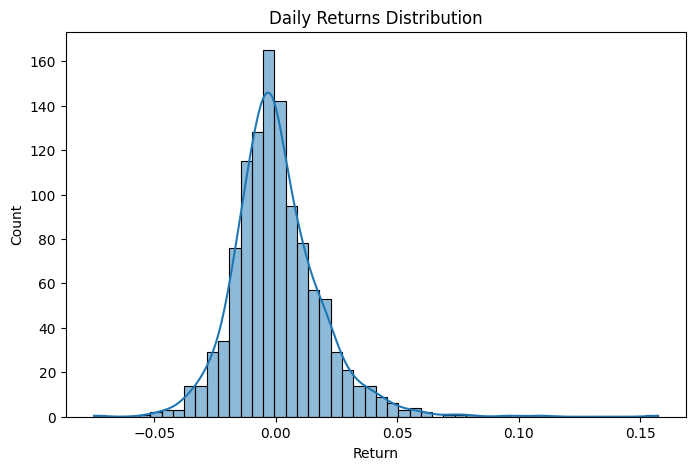

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(
    sample_df["Return"],
    bins=50,
    kde=True
)
plt.title("Daily Returns Distribution")
plt.show()

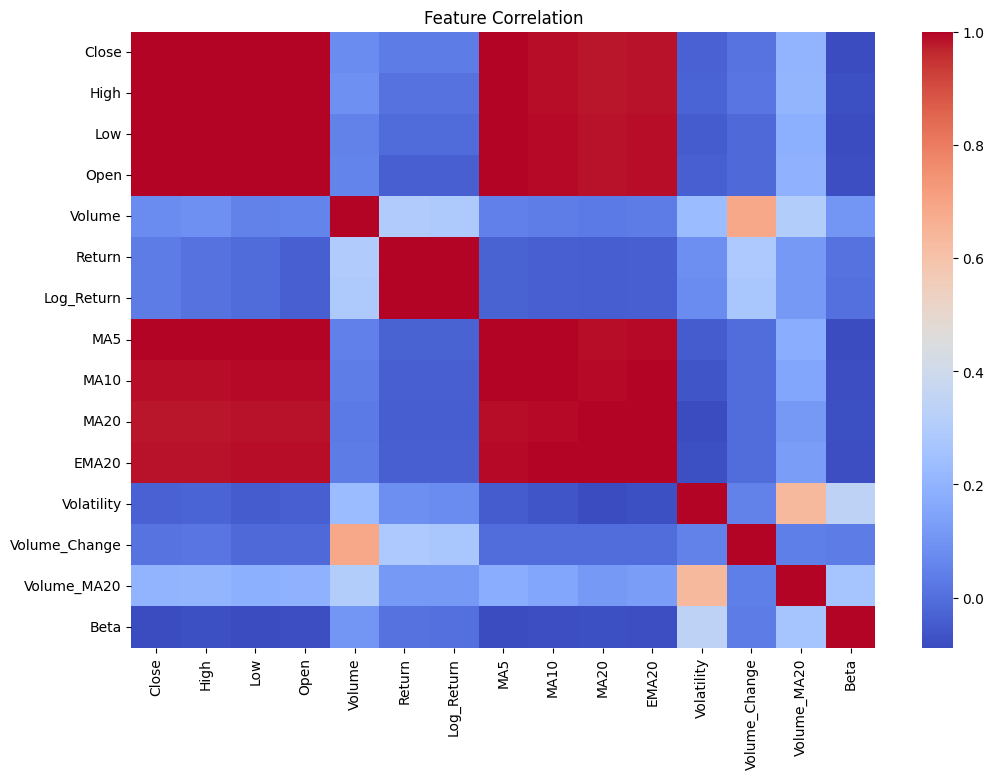

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(
    sample_df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation")
plt.show()

In [29]:
features = ["Close","Volume","Return","Log_Return","MA5","MA10","MA20","EMA20","Volatility","Volume_Change","Volume_MA20", "Beta"
]

print(features)

['Close', 'Volume', 'Return', 'Log_Return', 'MA5', 'MA10', 'MA20', 'EMA20', 'Volatility', 'Volume_Change', 'Volume_MA20', 'Beta']


In [30]:
scaler = StandardScaler()
sequence_length = 30
x_sequences = []
y_sequences = []
stock_names = []

In [31]:
processed_files = glob.glob(
    os.path.join(PROCESSED_PATH, "*.csv")
)
print(f"Total Processed Files : {len(processed_files)}")

Total Processed Files : 501


In [32]:
for file in tqdm(processed_files):

    try:
        df = pd.read_csv(file)
        if len(df) < sequence_length + 1:
            continue
        x = df[features].copy()
        scaler = StandardScaler()
        x_scaled = scaler.fit_transform(x)
        target = df["Return"].values

        for i in range(len(df) - sequence_length):
            x_sequences.append(
                x_scaled[i:i+sequence_length]
            )
            y_sequences.append(
                target[i+sequence_length]
            )
            stock_names.append(
                os.path.basename(file).replace(".csv","")
            )

    except:
        pass

100%|██████████| 501/501 [00:27<00:00, 18.23it/s]


In [33]:
x_sequences = np.array(x_sequences,dtype=np.float32)
y_sequences = np.array(y_sequences,dtype=np.float32)
print("Input :", x_sequences.shape)
print("Target :", y_sequences.shape)

Input : (416482, 30, 12)
Target : (416482,)


In [34]:
x_train, x_temp, y_train, y_temp = train_test_split(x_sequences,y_sequences,test_size=0.30,shuffle=False)

In [35]:
x_val, x_test, y_val, y_test = train_test_split(x_temp,y_temp,test_size=0.50,shuffle=False)

In [36]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(291537, 30, 12)
(62472, 30, 12)
(62473, 30, 12)


In [37]:
class StockDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(
            x,
            dtype=torch.float32
        )
        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [38]:
train_dataset = StockDataset(x_train,y_train)
val_dataset = StockDataset(x_val,y_val)
test_dataset = StockDataset(x_test,y_test)

In [39]:
torch.save(train_dataset,os.path.join(
        FINAL_PATH,
        "train_dataset.pt"))
torch.save(val_dataset,os.path.join(
        FINAL_PATH,
        "val_dataset.pt"))
torch.save(test_dataset,os.path.join(
        FINAL_PATH,
        "test_dataset.pt"))

In [40]:
batch_size = 32

train_loader = DataLoader( train_dataset,batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [41]:
batch_x, batch_y = next(iter(train_loader))
print(batch_x.shape)
print(batch_y.shape)

torch.Size([32, 30, 12])
torch.Size([32])


In [42]:
pd.DataFrame(
    {"features": features}
).to_csv(
    os.path.join(
        FINAL_PATH,
        "features.csv"
    ),
    index=False
)

In [43]:
print("Deliverable 1 Completed !!")

Deliverable 1 Completed !!
